In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

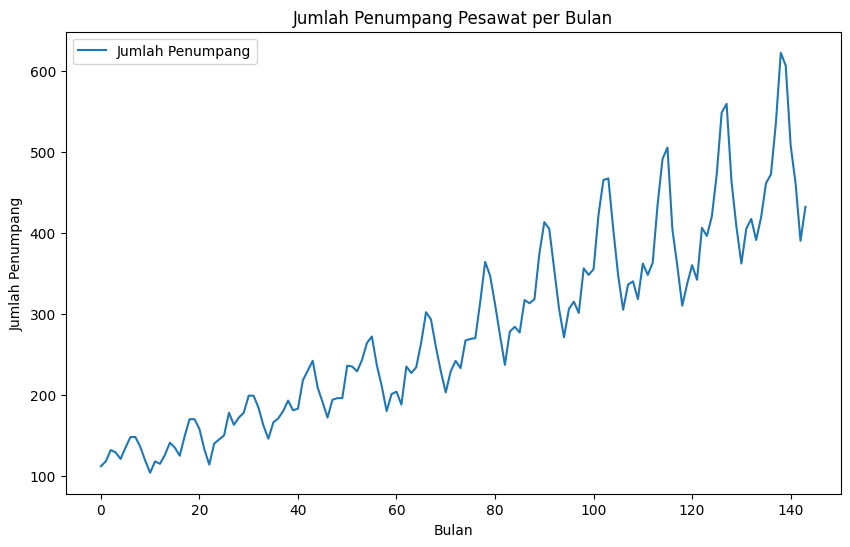

   Passengers
0         112
1         118
2         132
3         129
4         121


In [57]:
# Load dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url, usecols=[1])
data.columns = ['Passengers']
# Plot data
plt.figure(figsize=(10,6))
plt.plot(data, label='Jumlah Penumpang')
plt.title('Jumlah Penumpang Pesawat per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.show()
# Lihat 5 data teratas
print(data.head(n=5))

In [64]:
# Normalisasi data ke range [0,1]
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# Membuat data untuk supervised Learning
def create_dataset(dataset, time_step=5):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        X.append(a)
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

# Timestamp Percobaan
time_steps = [5,10,20]

results_original = {}
results_modified = {}

In [71]:
for ts in time_steps:
    print(f"\n{'='*30}")
    print(f"Time Step: {ts}")
    print(f"{'='*30}")

    # Membuat dataset
    X, y = create_dataset(data_scaled, ts)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Split train/test
    train_size = int(len(X) * 0.7)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    
    # MODEL ORIGINAL (1 HIDDEN LAYER)
    # Model RNN Original
    model_rnn = Sequential([
        SimpleRNN(50, return_sequences=False, input_shape=(ts, 1)),
        Dense(1)
    ])
    model_rnn.compile(optimizer='adam', loss='mean_squared_error')
    history_rnn = model_rnn.fit(X_train, y_train, validation_data=(X_test, y_test),
                                epochs=50, batch_size=16)

    # Model LSTM Original
    model_lstm = Sequential([
        LSTM(50, return_sequences=False, input_shape=(ts, 1)),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mean_squared_error')
    history_lstm = model_lstm.fit(X_train, y_train, validation_data=(X_test, y_test),
                                  epochs=50, batch_size=16)

    results_original[ts] = {
        'rnn_model': model_rnn,
        'lstm_model': model_lstm,
        'rnn_history': history_rnn,
        'lstm_history': history_lstm
    }
    
    # MODEL MODIFIED (2 HIDDEN LAYER)
    # Model RNN Modified
    model_rnn_mod = Sequential([
        SimpleRNN(50, return_sequences=True, input_shape=(ts, 1)),
        SimpleRNN(30, return_sequences=False),
        Dense(1)
    ])
    model_rnn_mod.compile(optimizer='adam', loss='mean_squared_error')
    history_rnn_mod = model_rnn_mod.fit(X_train, y_train, validation_data=(X_test, y_test),
                                epochs=50, batch_size=16)

    # Model LSTM Modified
    model_lstm_mod = Sequential([
        LSTM(50, return_sequences=True, input_shape=(ts, 1)),
        LSTM(30, return_sequences=False),
        Dense(1)
    ])
    model_lstm_mod.compile(optimizer='adam', loss='mean_squared_error')
    history_lstm_mod = model_lstm_mod.fit(X_train, y_train, validation_data=(X_test, y_test),
                                  epochs=50, batch_size=16)

    results_modified[ts] = {
        'rnn_model': model_rnn_mod,
        'lstm_model': model_lstm_mod,
        'rnn_history': history_rnn_mod,
        'lstm_history': history_lstm_mod
    }


Time Step: 5


c:\Users\Hary Capri\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0344 - val_loss: 0.0301
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0151 - val_loss: 0.0251
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052 - val_loss: 0.0550
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0071 - val_loss: 0.0156
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0045 - val_loss: 0.0141
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0027 - val_loss: 0.0189
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0030 - val_loss: 0.0202
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0028 - val_loss: 0.0124
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0030 - val_loss: 0.0141
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0025 - val_loss: 0.0153
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - val_loss: 0.0127
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021 - val_loss: 0.0125
E

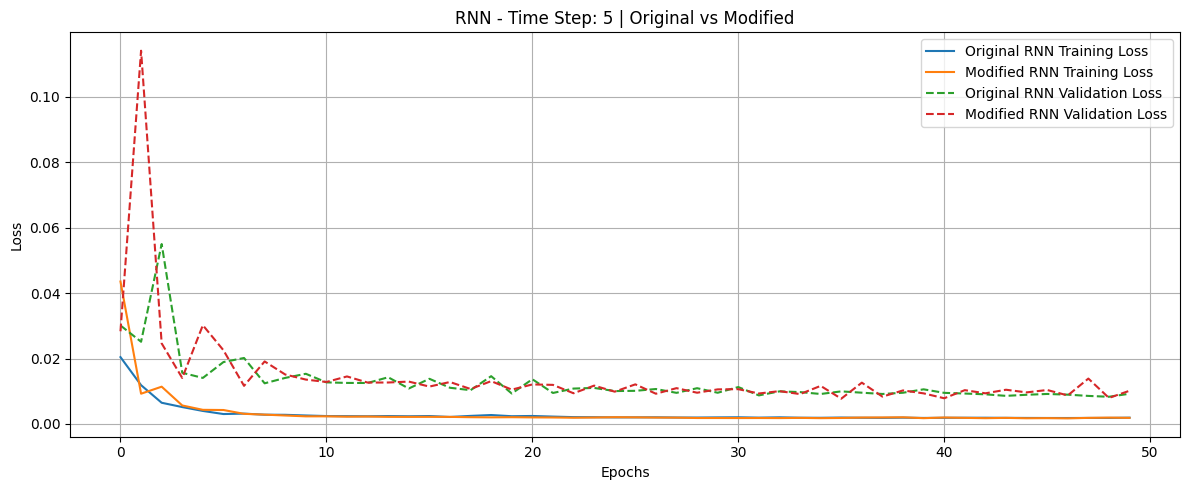

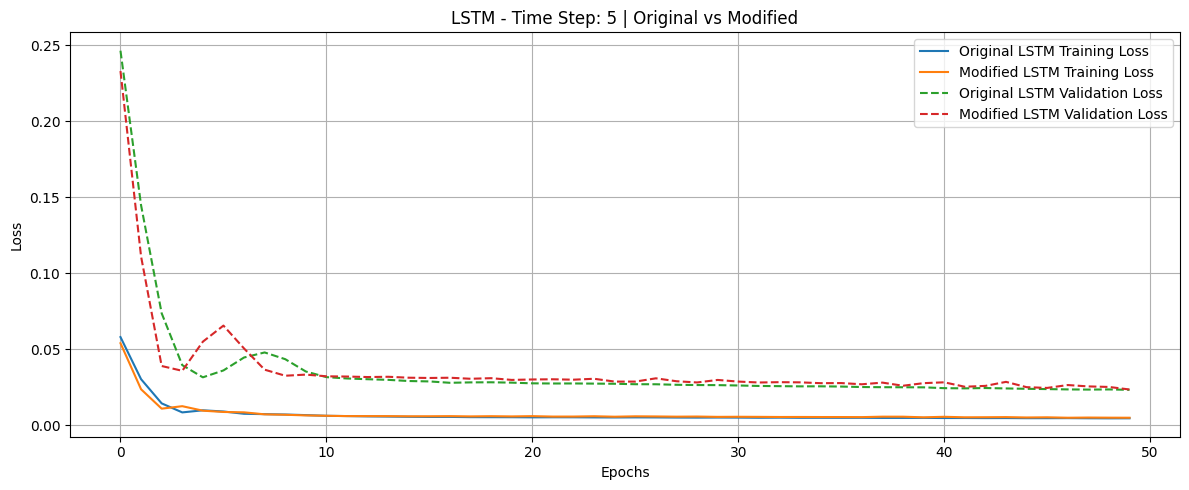

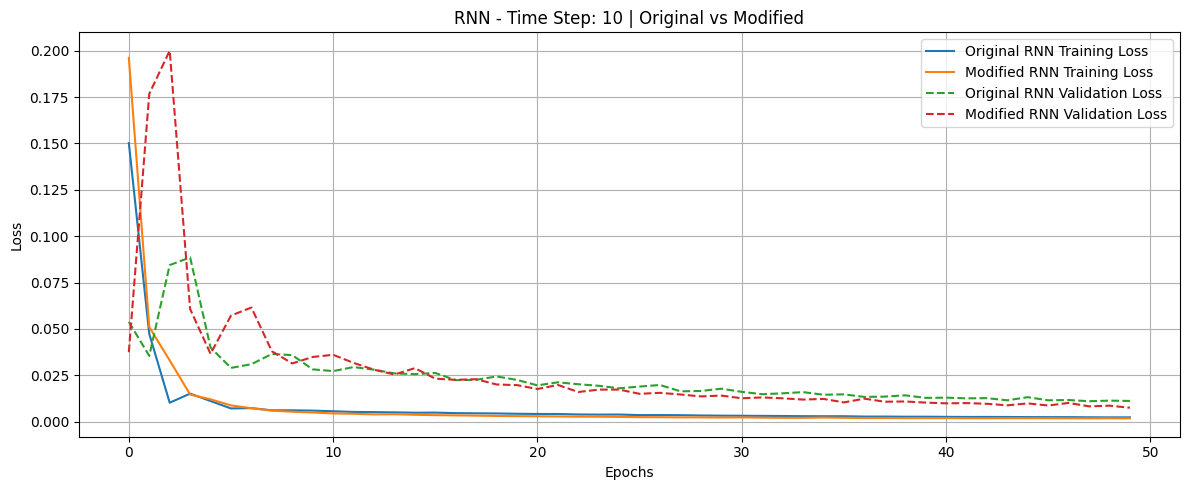

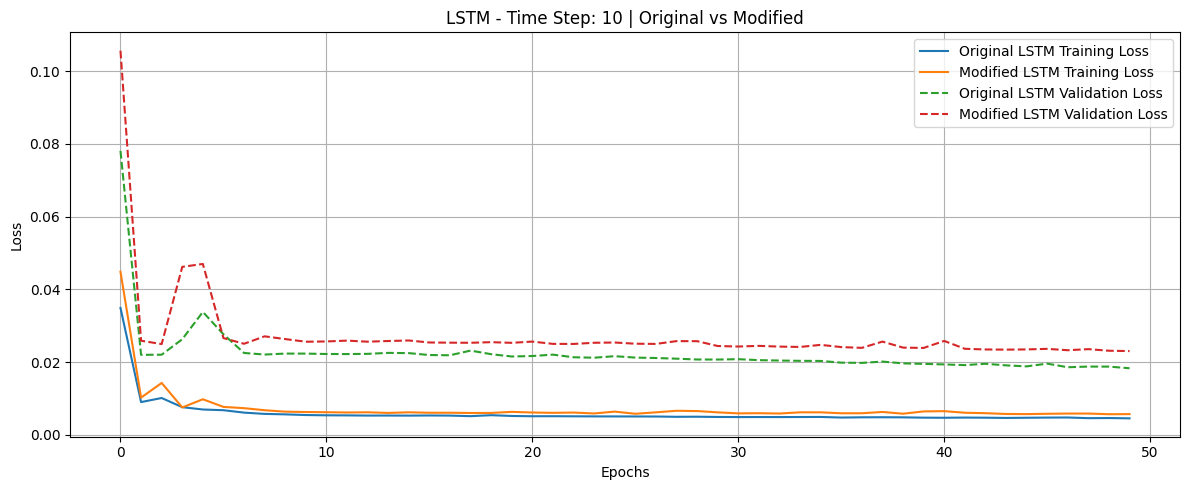

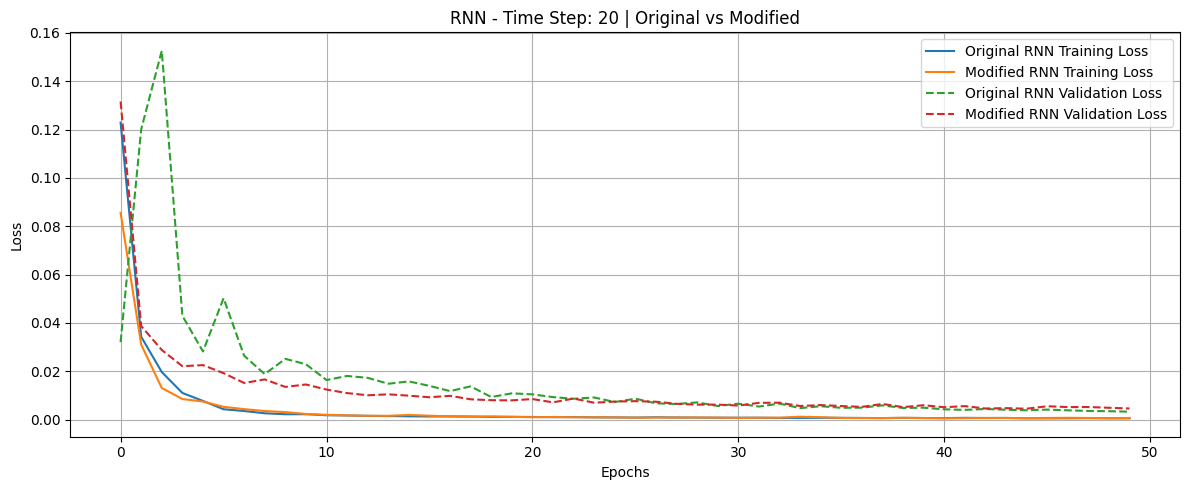

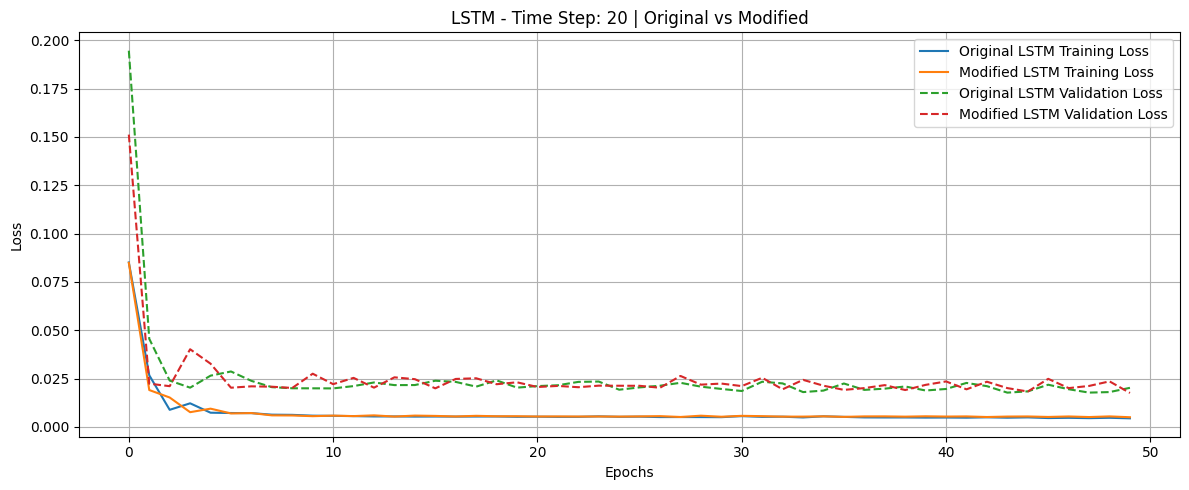

In [74]:
for idx, ts in enumerate(time_steps):
    orig_rnn = results_original[ts]['rnn_history'].history
    mod_rnn = results_modified[ts]['rnn_history'].history

    orig_lstm = results_original[ts]['lstm_history'].history
    mod_lstm = results_modified[ts]['lstm_history'].history

    # Figure baru untuk RNN
    plt.figure(figsize=(12, 5))
    plt.plot(orig_rnn['loss'], label='Original RNN Training Loss')
    plt.plot(mod_rnn['loss'], label='Modified RNN Training Loss')
    plt.plot(orig_rnn['val_loss'], '--', label='Original RNN Validation Loss')
    plt.plot(mod_rnn['val_loss'], '--', label='Modified RNN Validation Loss')
    plt.title(f'RNN - Time Step: {ts} | Original vs Modified')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Figure baru untuk LSTM
    plt.figure(figsize=(12, 5))
    plt.plot(orig_lstm['loss'], label='Original LSTM Training Loss')
    plt.plot(mod_lstm['loss'], label='Modified LSTM Training Loss')
    plt.plot(orig_lstm['val_loss'], '--', label='Original LSTM Validation Loss')
    plt.plot(mod_lstm['val_loss'], '--', label='Modified LSTM Validation Loss')
    plt.title(f'LSTM - Time Step: {ts} | Original vs Modified')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [75]:
for ts in time_steps:
    avg_rnn_orig = np.mean(results_original[ts]['rnn_history'].history['loss'])
    avg_rnn_mod = np.mean(results_modified[ts]['rnn_history'].history['loss'])

    avg_lstm_orig = np.mean(results_original[ts]['lstm_history'].history['loss'])
    avg_lstm_mod = np.mean(results_modified[ts]['lstm_history'].history['loss'])
    print(f"Time Step {ts}:")
    print(f"  RNN Original Average Loss : {avg_rnn_orig:.10f}")
    print(f"  RNN Modified Average Loss : {avg_rnn_mod:.10f}")
    print(f"  Delta RNN                 : {avg_rnn_mod - avg_rnn_orig:.10f}")
    print("-"*60)

    print(f"  LSTM Original Average Loss: {avg_lstm_orig:.10f}")
    print(f"  LSTM Modified Average Loss: {avg_lstm_mod:.10f}")
    print(f"  Delta LSTM                : {avg_lstm_mod - avg_lstm_orig:.10f}")
    print("="*60)

Time Step 5:
  RNN Original Average Loss : 0.0028843081
  RNN Modified Average Loss : 0.0033292778
  Delta RNN                 : 0.0004449697
------------------------------------------------------------
  LSTM Original Average Loss: 0.0072032507
  LSTM Modified Average Loss: 0.0074035949
  Delta LSTM                : 0.0002003442
Time Step 10:
  RNN Original Average Loss : 0.0081724003
  RNN Modified Average Loss : 0.0088614368
  Delta RNN                 : 0.0006890365
------------------------------------------------------------
  LSTM Original Average Loss: 0.0059273587
  LSTM Modified Average Loss: 0.0072624379
  Delta LSTM                : 0.0013350792
Time Step 20:
  RNN Original Average Loss : 0.0049659547
  RNN Modified Average Loss : 0.0040859548
  Delta RNN                 : -0.0008799999
------------------------------------------------------------
  LSTM Original Average Loss: 0.0075489515
  LSTM Modified Average Loss: 0.0077118890
  Delta LSTM                : 0.0001629376



Analisis Prediksi - Time Step: 5
Model Terbaik:
  RNN   -> Original
  LSTM  -> Original
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


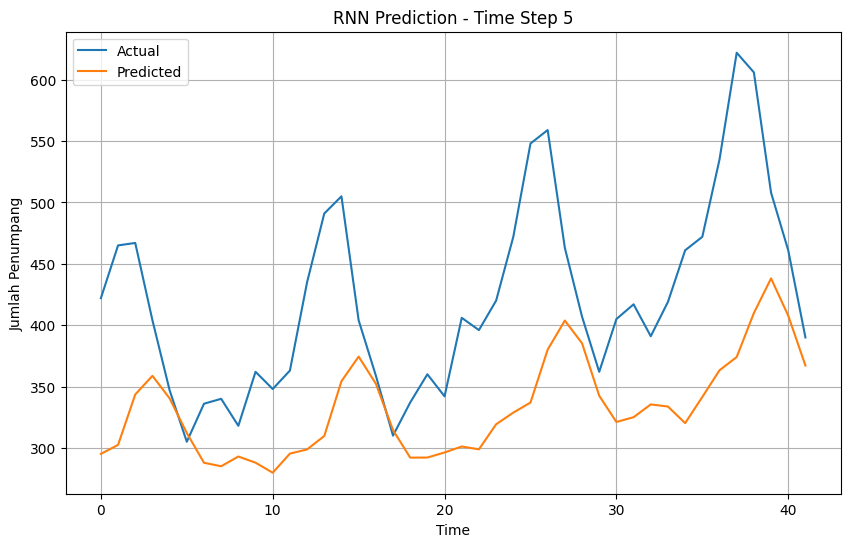

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


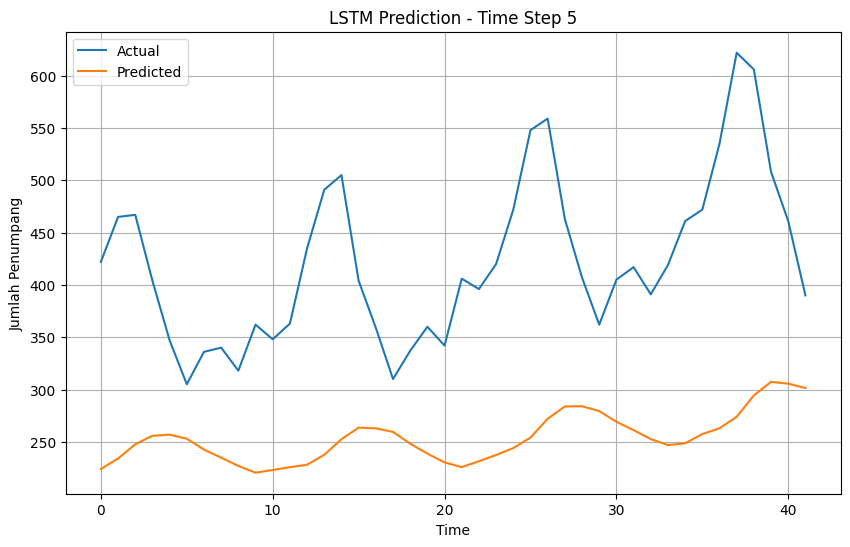

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Mean Absolute Error (MAE):
  Best RNN: 89.61 penumpang
  Best LSTM: 168.60 penumpang

Analisis Prediksi - Time Step: 10
Model Terbaik:
  RNN   -> Original
  LSTM  -> Original
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


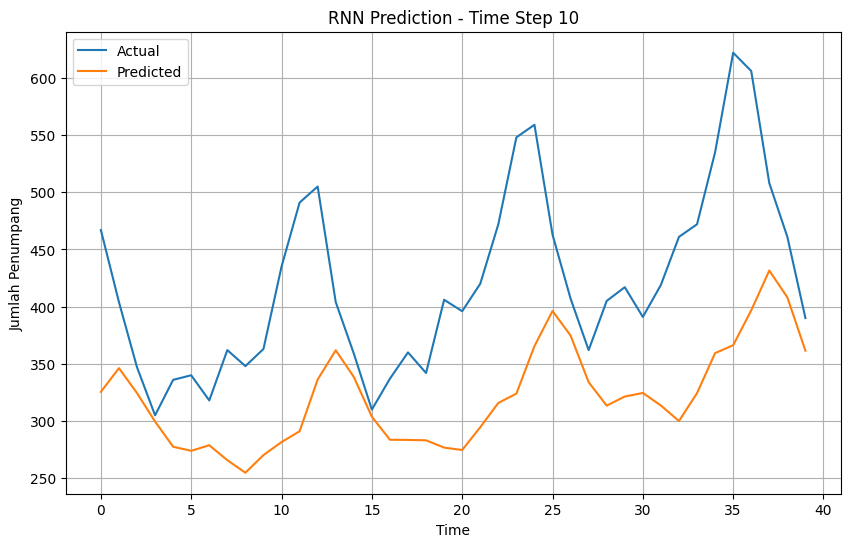

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 


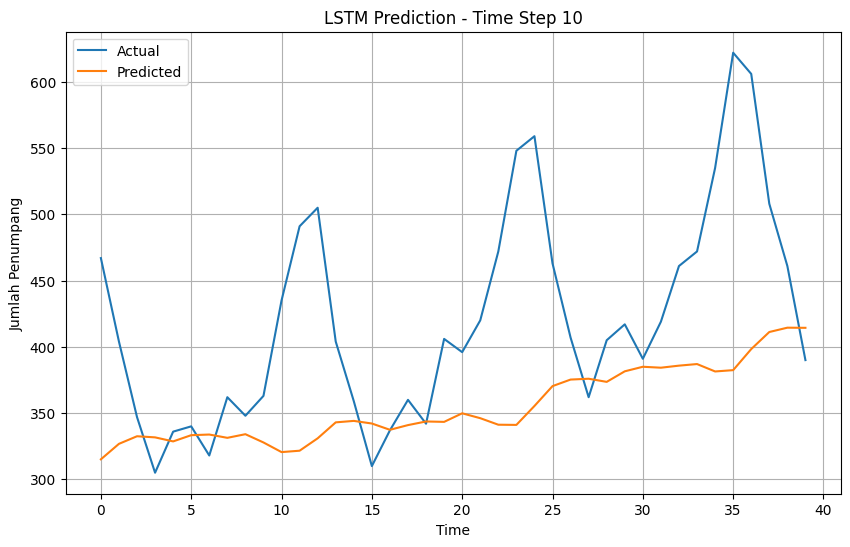

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Mean Absolute Error (MAE):
  Best RNN: 99.90 penumpang
  Best LSTM: 71.63 penumpang

Analisis Prediksi - Time Step: 20
Model Terbaik:
  RNN   -> Modified
  LSTM  -> Modified
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


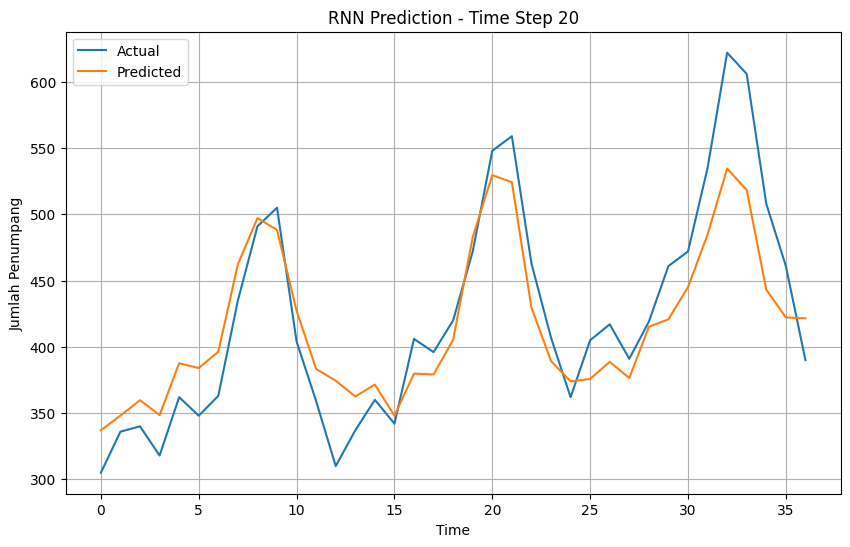

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


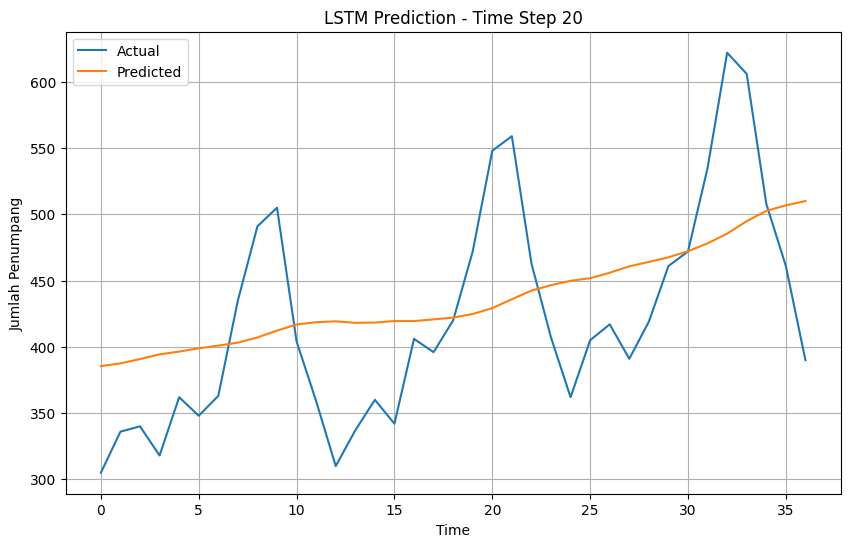

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Mean Absolute Error (MAE):
  Best RNN: 29.26 penumpang
  Best LSTM: 58.11 penumpang


In [ ]:
# Fungsi untuk plotting prediksi
def plot_predictions(model, X_test, y_test, scaler, title):
    predictions = model.predict(X_test)
    predictions_inverse = scaler.inverse_transform(predictions.reshape(-1, 1))
    y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

    plt.figure(figsize=(10,6))
    plt.plot(y_test_inverse, label='Actual')
    plt.plot(predictions_inverse, label='Predicted')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Jumlah Penumpang')
    plt.legend()
    plt.grid(True)
    plt.show()

# Loop analisis prediksi
for ts in time_steps:
    print(f"\n{'='*60}")
    print(f"Analisis Prediksi - Time Step: {ts}")
    print(f"{'='*60}")

    # Ambil model
    model_rnn_orig = results_original[ts]['rnn_model']
    model_lstm_orig = results_original[ts]['lstm_model']
    model_rnn_mod = results_modified[ts]['rnn_model']
    model_lstm_mod = results_modified[ts]['lstm_model']

    # Ambil data test
    X, y = create_dataset(data_scaled, ts)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    train_size = int(len(X) * 0.7)
    X_test = X[train_size:]
    y_test = y[train_size:]

    # Pilih model terbaik berdasarkan loss
    rnn_orig_loss = np.mean(results_original[ts]['rnn_history'].history['val_loss'])
    rnn_mod_loss = np.mean(results_modified[ts]['rnn_history'].history['val_loss'])
    lstm_orig_loss = np.mean(results_original[ts]['lstm_history'].history['val_loss'])
    lstm_mod_loss = np.mean(results_modified[ts]['lstm_history'].history['val_loss'])

    best_rnn = model_rnn_mod if rnn_mod_loss < rnn_orig_loss else model_rnn
    best_lstm = model_lstm_mod if lstm_mod_loss < lstm_orig_loss else model_lstm

    print("Model Terbaik:")
    print(f"  RNN   -> {'Modified' if rnn_mod_loss < rnn_orig_loss else 'Original'}")
    print(f"  LSTM  -> {'Modified' if lstm_mod_loss < lstm_orig_loss else 'Original'}")

    # Plot prediksi
    plot_predictions(best_rnn, X_test, y_test, scaler, f'RNN Prediction - Time Step {ts}')
    plot_predictions(best_lstm, X_test, y_test, scaler, f'LSTM Prediction - Time Step {ts}')

    # Hitung dan tampilkan error rata-rata absolut
    def mae(pred, true):
        return np.mean(np.abs(pred - true))

    pred_rnn = best_rnn.predict(X_test)
    pred_lstm = best_lstm.predict(X_test)

    pred_rnn_inv = scaler.inverse_transform(pred_rnn)
    pred_lstm_inv = scaler.inverse_transform(pred_lstm)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

    mae_rnn = mae(pred_rnn_inv, y_test_inv)
    mae_lstm = mae(pred_lstm_inv, y_test_inv)

    print(f"\nMean Absolute Error (MAE):")
    print(f"  Best RNN: {mae_rnn:.2f} penumpang")
    print(f"  Best LSTM: {mae_lstm:.2f} penumpang")

| Time Step | Terbaik RNN       | MAE RNN     | Terbaik LSTM       | MAE LSTM    |
|-----------|-------------------|-------------|--------------------|-------------|
| 5         | Original          | 89.61       | Original           | 168.60      |
| 10        | Original          | 99.90       | Original           | 71.63       |
| 20        | Modified (RNN+RNN)| **29.26** | Modified (LSTM+LSTM)| 58.11       |